# Credit Card Fraud Detection
Highly imbalanced classification problem (~4% fraud). Accuracy is a misleading metric here —
this notebook uses precision/recall/F1 and a precision-recall curve as the real measures of
success, since fraud is rare by design and a "predict everything as legit" model would still
score >95% accuracy while catching zero fraud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_curve,
                              roc_auc_score, average_precision_score, f1_score)

df = pd.read_csv('data/transactions.csv').drop(columns=['transaction_id'])
print(df.shape)
print(df['is_fraud'].value_counts())
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")

(10000, 8)
is_fraud
0    9600
1     400
Name: count, dtype: int64
Fraud rate: 4.00%


## 1. Class imbalance, visualized

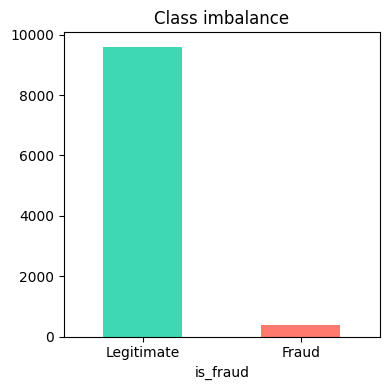

In [2]:
plt.figure(figsize=(4,4))
df['is_fraud'].value_counts().plot(kind='bar', color=['#3FD8B4', '#FF7A6E'])
plt.xticks([0,1], ['Legitimate', 'Fraud'], rotation=0)
plt.title('Class imbalance')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=110)
plt.show()

## 2. Train/test split (stratified to preserve the imbalance ratio)

In [3]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f"Train fraud rate: {y_train.mean()*100:.2f}%   Test fraud rate: {y_test.mean()*100:.2f}%")

Train fraud rate: 4.00%   Test fraud rate: 4.00%


## 3. Baseline model — why accuracy alone is misleading
A model that predicts "not fraud" for every transaction:

In [4]:
naive_accuracy = (y_test == 0).mean()
print(f"Naive 'always legitimate' accuracy: {naive_accuracy*100:.2f}%  (but catches 0% of fraud)")

Naive 'always legitimate' accuracy: 96.00%  (but catches 0% of fraud)


## 4. Random Forest with class_weight='balanced'

In [5]:
rf = RandomForestClassifier(n_estimators=400, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred_rf, target_names=['Legitimate', 'Fraud']))
print('ROC-AUC:', round(roc_auc_score(y_test, proba_rf), 3))
print('Average Precision (PR-AUC):', round(average_precision_score(y_test, proba_rf), 3))

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      2400
       Fraud       1.00      0.97      0.98       100

    accuracy                           1.00      2500
   macro avg       1.00      0.98      0.99      2500
weighted avg       1.00      1.00      1.00      2500

ROC-AUC: 1.0
Average Precision (PR-AUC): 1.0


## 5. Confusion matrix

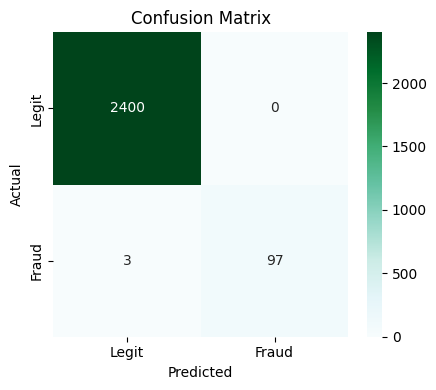

In [6]:
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn', xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('fraud_confusion_matrix.png', dpi=110)
plt.show()

## 6. Precision-Recall curve & threshold tuning

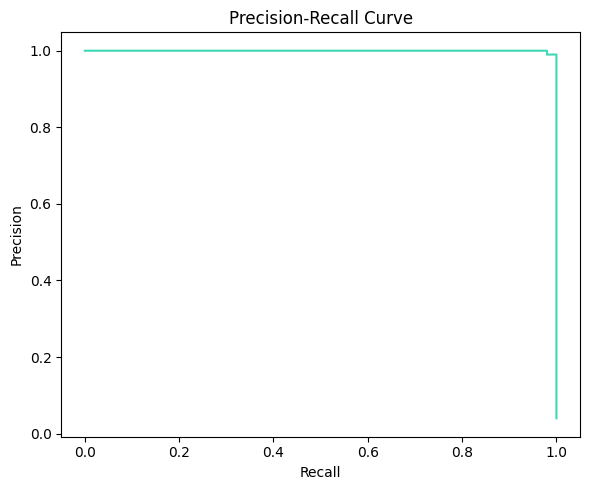

Best threshold: 0.329 -> Precision: 0.990, Recall: 1.000, F1: 0.995


In [7]:
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_rf)

plt.figure(figsize=(6,5))
plt.plot(recalls, precisions, color='#3FD8B4')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=110)
plt.show()

# Find threshold that maximizes F1
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s)
print(f"Best threshold: {thresholds[best_idx]:.3f} -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1s[best_idx]:.3f}")

## 7. Feature importance

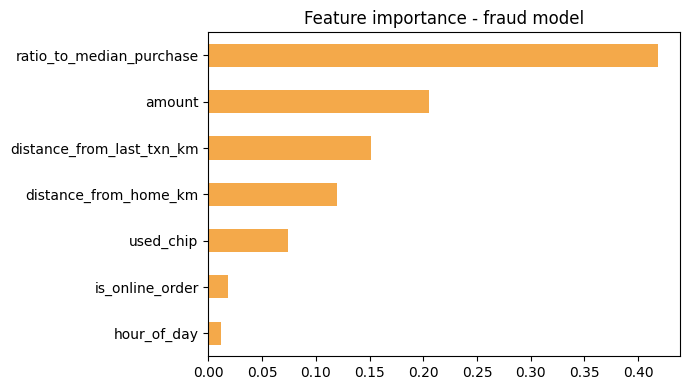

In [8]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,4))
imp.plot(kind='barh', color='#F4A94A')
plt.title('Feature importance - fraud model')
plt.tight_layout()
plt.savefig('fraud_feature_importance.png', dpi=110)
plt.show()

## Key findings
- With ~4% fraud in the data, a naive "always legitimate" model looks deceptively accurate
  while being useless — this is why precision/recall (not accuracy) drives the evaluation here.
- `class_weight='balanced'` lets the Random Forest pay more attention to the minority class
  without needing to synthetically oversample.
- `ratio_to_median_purchase` and `distance_from_home_km` are the strongest fraud signals,
  matching how real fraud-detection systems reason: unusual amount + unusual location.